# Deep & Cross Network (DCN) for Movie Recommendation

## Objective

In this notebook, we implement **Deep & Cross Network (DCN v1)** proposed by Google.

Unlike Wide & Deep, which requires manually engineered feature crosses, DCN automatically learns explicit feature interactions through Cross Layers.

The notebook covers:

1. Data preprocessing
2. Feature embeddings
3. Cross Network
4. Deep Network
5. DCN architecture
6. Model training
7. Model evaluation
8. Comparison with previous recommendation models

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (

    accuracy_score,

    roc_auc_score,

    roc_curve

)

import torch
import torch.nn as nn

from torch.utils.data import (

    Dataset,

    DataLoader

)

torch.manual_seed(42)

np.random.seed(42)

In [2]:
rating_columns = [

    "user_id",

    "movie_id",

    "rating",

    "timestamp"

]

ratings = pd.read_csv(

    "../data/u.data",

    sep="\t",

    names=rating_columns

)

ratings["user_id"] -= 1
ratings["movie_id"] -= 1

ratings.head()

,user_id,movie_id,rating,timestamp
0,195,241,3,881250949
1,185,301,3,891717742
2,21,376,1,878887116
3,243,50,2,880606923
4,165,345,1,886397596


In [3]:
user_columns = [

    "user_id",

    "age",

    "gender",

    "occupation",

    "zip_code"

]

users = pd.read_csv(

    "../data/u.user",

    sep="|",

    names=user_columns

)

users["user_id"] -= 1

users.head()

,user_id,age,gender,occupation,zip_code
0,0,24,M,technician,85711
1,1,53,F,other,94043
2,2,23,M,writer,32067
3,3,24,M,technician,43537
4,4,33,F,other,15213


In [4]:
movie_columns = [

    "movie_id",

    "title",

    "release_date",

    "video_release_date",

    "IMDb_URL"

]

genre_columns = [

    "unknown",

    "Action",

    "Adventure",

    "Animation",

    "Children",

    "Comedy",

    "Crime",

    "Documentary",

    "Drama",

    "Fantasy",

    "Film-Noir",

    "Horror",

    "Musical",

    "Mystery",

    "Romance",

    "Sci-Fi",

    "Thriller",

    "War",

    "Western"

]

movie_columns += genre_columns

movies = pd.read_csv(

    "../data/u.item",

    sep="|",

    encoding="latin-1",

    names=movie_columns

)

movies["movie_id"] -= 1

movies.head()

,movie_id,title,release_date,video_release_date,IMDb_URL,unknown,Action,Adventure,Animation,Children,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,0,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,1,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,2,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,3,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [5]:
data = ratings.merge(

    users,

    on="user_id"

)

data = data.merge(

    movies,

    on="movie_id"

)

data.head()

,user_id,movie_id,rating,timestamp,age,gender,occupation,zip_code,title,release_date,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,195,241,3,881250949,49,M,writer,55105,Kolya (1996),24-Jan-1997,...,0,0,0,0,0,0,0,0,0,0
1,185,301,3,891717742,39,F,executive,00000,L.A. Confidential (1997),01-Jan-1997,...,0,1,0,0,1,0,0,1,0,0
2,21,376,1,878887116,25,M,writer,40206,Heavyweights (1994),01-Jan-1994,...,0,0,0,0,0,0,0,0,0,0
3,243,50,2,880606923,28,M,technician,80525,Legends of the Fall (1994),01-Jan-1994,...,0,0,0,0,0,1,0,0,1,1
4,165,345,1,886397596,47,M,educator,55113,Jackie Brown (1997),01-Jan-1997,...,0,0,0,0,0,0,0,0,0,0


In [6]:
data["label"] = (

    data["rating"] >= 4

).astype(np.float32)

data[["rating","label"]].head()

,rating,label
0,3,0.0
1,3,0.0
2,1,0.0
3,2,0.0
4,1,0.0


In [7]:
train_df, test_df = train_test_split(

    data,

    test_size=0.2,

    random_state=42,

    stratify=data["label"]

)

In [8]:
gender_encoder = LabelEncoder()

occupation_encoder = LabelEncoder()

train_df["gender_idx"] = gender_encoder.fit_transform(

    train_df["gender"]

)

test_df["gender_idx"] = gender_encoder.transform(

    test_df["gender"]

)

train_df["occupation_idx"] = occupation_encoder.fit_transform(

    train_df["occupation"]

)

test_df["occupation_idx"] = occupation_encoder.transform(

    test_df["occupation"]

)

max_age = train_df["age"].max()

train_df["age"] /= max_age

test_df["age"] /= max_age

In [9]:
NUM_USERS = data["user_id"].nunique()

NUM_MOVIES = data["movie_id"].nunique()

NUM_GENDERS = len(

    gender_encoder.classes_

)

NUM_OCCUPATIONS = len(

    occupation_encoder.classes_

)

print(NUM_USERS)

print(NUM_MOVIES)

print(NUM_GENDERS)

print(NUM_OCCUPATIONS)

943
1682
2
21


In [10]:
class DCNDataset(Dataset):

    def __init__(self, dataframe):

        self.user = torch.LongTensor(
            dataframe["user_id"].values
        )

        self.movie = torch.LongTensor(
            dataframe["movie_id"].values
        )

        self.gender = torch.LongTensor(
            dataframe["gender_idx"].values
        )

        self.occupation = torch.LongTensor(
            dataframe["occupation_idx"].values
        )

        self.age = torch.FloatTensor(
            dataframe["age"].values
        )

        self.genres = torch.FloatTensor(
            dataframe[genre_columns].values
        )

        self.labels = torch.FloatTensor(
            dataframe["label"].values
        )

    def __len__(self):

        return len(self.labels)

    def __getitem__(self, idx):

        return (

            self.user[idx],

            self.movie[idx],

            self.gender[idx],

            self.occupation[idx],

            self.age[idx],

            self.genres[idx],

            self.labels[idx]

        )

In [11]:
train_dataset = DCNDataset(
    train_df
)

test_dataset = DCNDataset(
    test_df
)
train_loader = DataLoader(

    train_dataset,

    batch_size=512,

    shuffle=True

)

test_loader = DataLoader(

    test_dataset,

    batch_size=512,

    shuffle=False

)

In [12]:
batch = next(
    iter(train_loader)
)

for tensor in batch:

    print(
        tensor.shape
    )

torch.Size([512])
torch.Size([512])
torch.Size([512])
torch.Size([512])
torch.Size([512])
torch.Size([512, 19])
torch.Size([512])


In [13]:
class FeatureEmbedding(nn.Module):

    def __init__(

        self,

        num_users,

        num_movies,

        num_genders,

        num_occupations,

        embedding_dim=16

    ):

        super().__init__()

        self.user_embedding = nn.Embedding(
            num_users,
            embedding_dim
        )

        self.movie_embedding = nn.Embedding(
            num_movies,
            embedding_dim
        )

        self.gender_embedding = nn.Embedding(
            num_genders,
            embedding_dim
        )

        self.occupation_embedding = nn.Embedding(
            num_occupations,
            embedding_dim
        )

        self.age_projection = nn.Linear(
            1,
            embedding_dim
        )

        self.genre_projection = nn.Linear(
            len(genre_columns),
            embedding_dim
        )

    def forward(

        self,

        user,

        movie,

        gender,

        occupation,

        age,

        genres

    ):

        user_emb = self.user_embedding(user)

        movie_emb = self.movie_embedding(movie)

        gender_emb = self.gender_embedding(gender)

        occupation_emb = self.occupation_embedding(
            occupation
        )

        age_emb = self.age_projection(
            age.unsqueeze(1)
        )

        genre_emb = self.genre_projection(
            genres
        )

        return torch.cat(

            [

                user_emb,

                movie_emb,

                gender_emb,

                occupation_emb,

                age_emb,

                genre_emb

            ],

            dim=1

        )

In [14]:
embedding_layer = FeatureEmbedding(

    NUM_USERS,

    NUM_MOVIES,

    NUM_GENDERS,

    NUM_OCCUPATIONS,

    embedding_dim=16

)

batch = next(iter(train_loader))

features = embedding_layer(

    batch[0],

    batch[1],

    batch[2],

    batch[3],

    batch[4],

    batch[5]

)

print(features.shape)

torch.Size([512, 96])


In [15]:
class CrossLayer(nn.Module):

    def __init__(

        self,

        input_dim

    ):

        super().__init__()

        self.weight = nn.Parameter(

            torch.randn(input_dim)

        )

        self.bias = nn.Parameter(

            torch.zeros(input_dim)

        )

    def forward(

        self,

        x0,

        x

    ):

        cross = torch.sum(

            x * self.weight,

            dim=1,

            keepdim=True

        )

        out = (

            x0 * cross

            + self.bias

            + x

        )

        return out

In [16]:
cross_layer = CrossLayer(

    input_dim=96

)

batch = next(

    iter(train_loader)

)

x0 = embedding_layer(

    batch[0],

    batch[1],

    batch[2],

    batch[3],

    batch[4],

    batch[5]

)

x1 = cross_layer(

    x0,

    x0

)

print(

    x1.shape

)

torch.Size([512, 96])


In [17]:
class CrossNetwork(nn.Module):

    def __init__(

        self,

        input_dim,

        num_layers=3

    ):

        super().__init__()

        self.layers = nn.ModuleList(

            [

                CrossLayer(input_dim)

                for _ in range(num_layers)

            ]

        )

    def forward(

        self,

        x0

    ):

        x = x0

        for layer in self.layers:

            x = layer(

                x0,

                x

            )

        return x

In [18]:
cross_network = CrossNetwork(

    input_dim=96,

    num_layers=3

)

cross_output = cross_network(

    x0

)

print(

    cross_output.shape

)

torch.Size([512, 96])


In [19]:
class DeepNetwork(nn.Module):

    def __init__(

        self,

        input_dim

    ):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(

                input_dim,

                256

            ),

            nn.ReLU(),

            nn.Dropout(0.2),

            nn.Linear(

                256,

                128

            ),

            nn.ReLU(),

            nn.Dropout(0.2),

            nn.Linear(

                128,

                96

            )

        )

    def forward(

        self,

        x

    ):

        return self.network(

            x

        )

In [20]:
deep_network = DeepNetwork(

    input_dim=96

)

deep_output = deep_network(

    x0

)

print(

    deep_output.shape

)

torch.Size([512, 96])


In [21]:
combined = torch.cat(

    [

        cross_output,

        deep_output

    ],

    dim=1

)

print(

    combined.shape

)

torch.Size([512, 192])


In [22]:
class DCN(nn.Module):

    def __init__(

        self,

        num_users,

        num_movies,

        num_genders,

        num_occupations,

        embedding_dim=16,

        num_cross_layers=3

    ):

        super().__init__()

        self.embedding = FeatureEmbedding(

            num_users,

            num_movies,

            num_genders,

            num_occupations,

            embedding_dim

        )

        input_dim = embedding_dim * 6

        self.cross_network = CrossNetwork(

            input_dim,

            num_cross_layers

        )

        self.deep_network = DeepNetwork(

            input_dim

        )

        self.output_layer = nn.Linear(

            input_dim * 2,

            1

        )

    def forward(

        self,

        user,

        movie,

        gender,

        occupation,

        age,

        genres

    ):

        x0 = self.embedding(

            user,

            movie,

            gender,

            occupation,

            age,

            genres

        )

        cross_output = self.cross_network(

            x0

        )

        deep_output = self.deep_network(

            x0

        )

        combined = torch.cat(

            [

                cross_output,

                deep_output

            ],

            dim=1

        )

        output = self.output_layer(

            combined

        )

        return output.squeeze()

In [23]:
model = DCN(

    num_users=NUM_USERS,

    num_movies=NUM_MOVIES,

    num_genders=NUM_GENDERS,

    num_occupations=NUM_OCCUPATIONS,

    embedding_dim=16,

    num_cross_layers=3

)

model

DCN(
  (embedding): FeatureEmbedding(
    (user_embedding): Embedding(943, 16)
    (movie_embedding): Embedding(1682, 16)
    (gender_embedding): Embedding(2, 16)
    (occupation_embedding): Embedding(21, 16)
    (age_projection): Linear(in_features=1, out_features=16, bias=True)
    (genre_projection): Linear(in_features=19, out_features=16, bias=True)
  )
  (cross_network): CrossNetwork(
    (layers): ModuleList(
      (0-2): 3 x CrossLayer()
    )
  )
  (deep_network): DeepNetwork(
    (network): Sequential(
      (0): Linear(in_features=96, out_features=256, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.2, inplace=False)
      (3): Linear(in_features=256, out_features=128, bias=True)
      (4): ReLU()
      (5): Dropout(p=0.2, inplace=False)
      (6): Linear(in_features=128, out_features=96, bias=True)
    )
  )
  (output_layer): Linear(in_features=192, out_features=1, bias=True)
)

In [24]:
batch = next(

    iter(train_loader)

)

outputs = model(

    batch[0],

    batch[1],

    batch[2],

    batch[3],

    batch[4],

    batch[5]

)

print(outputs.shape)

torch.Size([512])


In [25]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(

    model.parameters(),

    lr=0.001

)

In [26]:
batch = next(

    iter(train_loader)

)

optimizer.zero_grad()

outputs = model(

    batch[0],

    batch[1],

    batch[2],

    batch[3],

    batch[4],

    batch[5]

)

loss = criterion(

    outputs,

    batch[6]

)

loss.backward()

optimizer.step()

print(

    "Loss:",

    loss.item()

)

Loss: 17.582393646240234


In [27]:
def train_model(

    model,

    train_loader,

    criterion,

    optimizer,

    epochs=20

):

    print("Training DCN...")

    history = []

    for epoch in range(epochs):

        model.train()

        running_loss = 0.0

        for (

            user,

            movie,

            gender,

            occupation,

            age,

            genres,

            labels

        ) in train_loader:

            optimizer.zero_grad()

            outputs = model(

                user,

                movie,

                gender,

                occupation,

                age,

                genres

            )

            loss = criterion(

                outputs,

                labels

            )

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)

        history.append(

            epoch_loss

        )

        print(

            f"Epoch {epoch+1:2d}/{epochs} | Loss = {epoch_loss:.4f}"

        )

    return history

In [28]:
history = train_model(

    model,

    train_loader,

    criterion,

    optimizer,

    epochs=20

)

Training DCN...
Epoch  1/20 | Loss = 3.3710
Epoch  2/20 | Loss = 0.7263
Epoch  3/20 | Loss = 0.7096
Epoch  4/20 | Loss = 0.6985
Epoch  5/20 | Loss = 0.6733
Epoch  6/20 | Loss = 0.6595
Epoch  7/20 | Loss = 0.6514
Epoch  8/20 | Loss = 0.6359
Epoch  9/20 | Loss = 0.6242
Epoch 10/20 | Loss = 0.6143
Epoch 11/20 | Loss = 0.6076
Epoch 12/20 | Loss = 0.5965
Epoch 13/20 | Loss = 0.5895
Epoch 14/20 | Loss = 0.5796
Epoch 15/20 | Loss = 0.5746
Epoch 16/20 | Loss = 0.5622
Epoch 17/20 | Loss = 0.5595
Epoch 18/20 | Loss = 0.5509
Epoch 19/20 | Loss = 0.5442
Epoch 20/20 | Loss = 0.5357


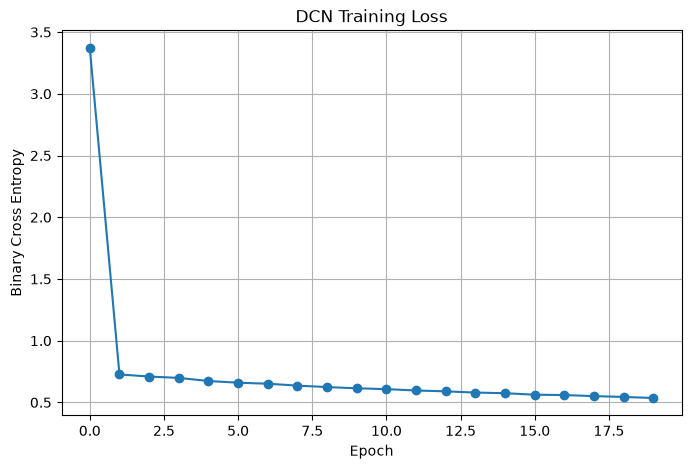

In [29]:
plt.figure(figsize=(8,5))

plt.plot(

    history,

    marker="o"

)

plt.title("DCN Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Binary Cross Entropy")

plt.grid(True)

plt.show()

In [30]:
def evaluate_model(

    model,

    test_loader

):

    model.eval()

    probabilities = []

    predictions = []

    labels = []

    with torch.no_grad():

        for (

            user,

            movie,

            gender,

            occupation,

            age,

            genres,

            target

        ) in test_loader:

            logits = model(

                user,

                movie,

                gender,

                occupation,

                age,

                genres

            )

            probs = torch.sigmoid(

                logits

            )

            preds = (

                probs >= 0.5

            ).float()

            probabilities.extend(

                probs.cpu().numpy()

            )

            predictions.extend(

                preds.cpu().numpy()

            )

            labels.extend(

                target.cpu().numpy()

            )

    accuracy = accuracy_score(

        labels,

        predictions

    )

    auc = roc_auc_score(

        labels,

        probabilities

    )

    return (

        accuracy,

        auc,

        np.array(probabilities),

        np.array(predictions),

        np.array(labels)

    )

In [31]:
accuracy, auc, probabilities, predictions, labels = evaluate_model(

    model,

    test_loader

)

print(

    f"Accuracy : {accuracy:.4f}"

)

print(

    f"AUC : {auc:.4f}"

)

Accuracy : 0.6681
AUC : 0.7317


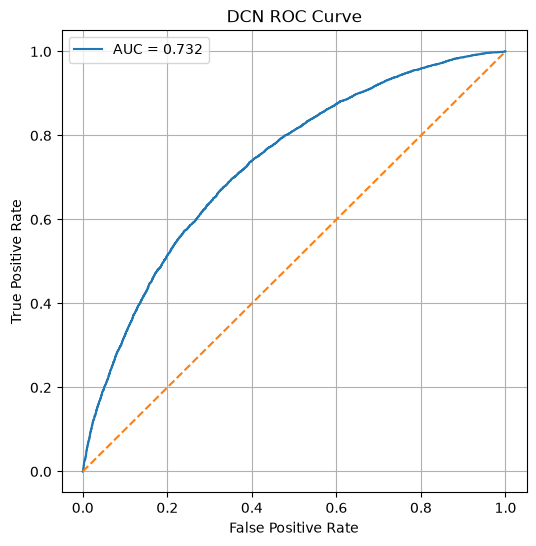

In [32]:
fpr, tpr, _ = roc_curve(

    labels,

    probabilities

)

plt.figure(figsize=(6,6))

plt.plot(

    fpr,

    tpr,

    label=f"AUC = {auc:.3f}"

)

plt.plot(

    [0,1],

    [0,1],

    "--"

)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("DCN ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

In [33]:
prediction_df = test_df.copy()

prediction_df["probability"] = probabilities

prediction_df["prediction"] = predictions

prediction_df.head()

,user_id,movie_id,rating,timestamp,age,gender,occupation,zip_code,title,release_date,...,Romance,Sci-Fi,Thriller,War,Western,label,gender_idx,occupation_idx,probability,prediction
70309,406,152,4,875042569,0.397260,M,engineer,03261,"Fish Called Wanda, A (1988)",01-Jan-1988,...,0,0,0,0,0,1.0,1,4,0.535095,1.0
14503,241,290,3,879740593,0.452055,M,educator,31404,Absolute Power (1997),14-Feb-1997,...,0,0,1,0,0,0.0,1,3,0.837979,1.0
22229,329,237,5,876546323,0.479452,F,educator,33884,Raising Arizona (1987),01-Jan-1987,...,0,0,0,0,0,1.0,0,3,0.965335,1.0
34450,403,753,3,883790218,0.397260,F,programmer,55108,Red Corner (1997),01-Jan-1997,...,0,0,1,0,0,0.0,0,14,0.464732,0.0
28502,325,43,1,879875852,0.561644,M,administrator,15235,Dolores Claiborne (1994),01-Jan-1994,...,0,0,1,0,0,0.0,1,0,0.377513,0.0


In [34]:
def precision_at_k(

    prediction_df,

    k=10

):

    precisions = []

    grouped = prediction_df.groupby(

        "user_id"

    )

    for _, group in grouped:

        top_k = group.sort_values(

            "probability",

            ascending=False

        ).head(k)

        precisions.append(

            top_k["label"].mean()

        )

    return np.mean(

        precisions

    )

In [35]:
def recall_at_k(

    prediction_df,

    k=10

):

    recalls = []

    grouped = prediction_df.groupby(

        "user_id"

    )

    for _, group in grouped:

        relevant = group["label"].sum()

        if relevant == 0:

            continue

        top_k = group.sort_values(

            "probability",

            ascending=False

        ).head(k)

        hits = top_k["label"].sum()

        recalls.append(

            hits / relevant

        )

    return np.mean(

        recalls

    )

In [36]:
def hit_rate_at_k(

    prediction_df,

    k=10

):

    hits = []

    grouped = prediction_df.groupby(

        "user_id"

    )

    for _, group in grouped:

        top_k = group.sort_values(

            "probability",

            ascending=False

        ).head(k)

        hits.append(

            top_k["label"].sum() > 0

        )

    return np.mean(

        hits

    )

In [37]:
precision = precision_at_k(

    prediction_df,

    k=10

)

recall = recall_at_k(

    prediction_df,

    k=10

)

hitrate = hit_rate_at_k(

    prediction_df,

    k=10

)

metrics = pd.DataFrame(

    {

        "Metric":[

            "Accuracy",

            "AUC",

            "Precision@10",

            "Recall@10",

            "HitRate@10"

        ],

        "Value":[

            accuracy,

            auc,

            precision,

            recall,

            hitrate

        ]

    }

)

metrics

,Metric,Value
0,Accuracy,0.668100
1,AUC,0.731729
2,Precision@10,0.648026
3,Recall@10,0.714162
4,HitRate@10,0.975610


In [38]:
prediction_df[[

    "user_id",

    "movie_id",

    "label",

    "probability",

    "prediction"

]].sample(20)

,user_id,movie_id,label,probability,prediction
61642,663,275,1.0,0.772314,1.0
11962,302,299,0.0,0.106210,0.0
7817,327,1247,0.0,0.141581,0.0
18602,322,242,0.0,0.060991,0.0
68880,933,296,1.0,0.860317,1.0
56458,737,256,0.0,0.905480,1.0
58851,862,300,1.0,0.324870,0.0
45274,706,301,1.0,0.531644,1.0
53872,298,98,0.0,0.510359,1.0
42255,302,149,1.0,0.747430,1.0


In [39]:
comparison = pd.DataFrame(

    {

        "Model":[

            "Ranking MLP",

            "Wide & Deep",

            "DeepFM",

            "DLRM",

            "DCN"

        ],

        "Accuracy":[

            0.8400,

            0.8334,

            0.6816,

            0.7084,

            accuracy

        ],

        "AUC":[

            0.7862,

            0.7763,

            0.7386,

            0.7739,

            auc

        ],

        "Precision@10":[

            0.9102,

            0.8831,

            0.6500,

            0.6632,

            precision

        ],

        "Recall@10":[

            0.5092,

            0.6886,

            0.7169,

            0.7264,

            recall

        ],

        "HitRate@10":[

            0.9978,

            0.9957,

            0.9767,

            0.9777,

            hitrate

        ]

    }

)

comparison

,Model,Accuracy,AUC,Precision@10,Recall@10,HitRate@10
0,Ranking MLP,0.8400,0.786200,0.910200,0.509200,0.99780
1,Wide & Deep,0.8334,0.776300,0.883100,0.688600,0.99570
2,DeepFM,0.6816,0.738600,0.650000,0.716900,0.97670
3,DLRM,0.7084,0.773900,0.663200,0.726400,0.97770
4,DCN,0.6681,0.731729,0.648026,0.714162,0.97561


In [40]:
print("Best Accuracy")

display(

    comparison.sort_values(

        "Accuracy",

        ascending=False

    )

)

print("Best AUC")

display(

    comparison.sort_values(

        "AUC",

        ascending=False

    )

)

print("Best Precision@10")

display(

    comparison.sort_values(

        "Precision@10",

        ascending=False

    )

)

print("Best Recall@10")

display(

    comparison.sort_values(

        "Recall@10",

        ascending=False

    )

)

print("Best HitRate@10")

display(

    comparison.sort_values(

        "HitRate@10",

        ascending=False

    )

)

Best Accuracy


,Model,Accuracy,AUC,Precision@10,Recall@10,HitRate@10
0,Ranking MLP,0.8400,0.786200,0.910200,0.509200,0.99780
1,Wide & Deep,0.8334,0.776300,0.883100,0.688600,0.99570
3,DLRM,0.7084,0.773900,0.663200,0.726400,0.97770
2,DeepFM,0.6816,0.738600,0.650000,0.716900,0.97670
4,DCN,0.6681,0.731729,0.648026,0.714162,0.97561


Best AUC


,Model,Accuracy,AUC,Precision@10,Recall@10,HitRate@10
0,Ranking MLP,0.8400,0.786200,0.910200,0.509200,0.99780
1,Wide & Deep,0.8334,0.776300,0.883100,0.688600,0.99570
3,DLRM,0.7084,0.773900,0.663200,0.726400,0.97770
2,DeepFM,0.6816,0.738600,0.650000,0.716900,0.97670
4,DCN,0.6681,0.731729,0.648026,0.714162,0.97561


Best Precision@10


,Model,Accuracy,AUC,Precision@10,Recall@10,HitRate@10
0,Ranking MLP,0.8400,0.786200,0.910200,0.509200,0.99780
1,Wide & Deep,0.8334,0.776300,0.883100,0.688600,0.99570
3,DLRM,0.7084,0.773900,0.663200,0.726400,0.97770
2,DeepFM,0.6816,0.738600,0.650000,0.716900,0.97670
4,DCN,0.6681,0.731729,0.648026,0.714162,0.97561


Best Recall@10


,Model,Accuracy,AUC,Precision@10,Recall@10,HitRate@10
3,DLRM,0.7084,0.773900,0.663200,0.726400,0.97770
2,DeepFM,0.6816,0.738600,0.650000,0.716900,0.97670
4,DCN,0.6681,0.731729,0.648026,0.714162,0.97561
1,Wide & Deep,0.8334,0.776300,0.883100,0.688600,0.99570
0,Ranking MLP,0.8400,0.786200,0.910200,0.509200,0.99780


Best HitRate@10


,Model,Accuracy,AUC,Precision@10,Recall@10,HitRate@10
0,Ranking MLP,0.8400,0.786200,0.910200,0.509200,0.99780
1,Wide & Deep,0.8334,0.776300,0.883100,0.688600,0.99570
3,DLRM,0.7084,0.773900,0.663200,0.726400,0.97770
2,DeepFM,0.6816,0.738600,0.650000,0.716900,0.97670
4,DCN,0.6681,0.731729,0.648026,0.714162,0.97561


# Conclusion

In this notebook, we implemented **Deep & Cross Network (DCN v1)** proposed by Google.

Unlike Wide & Deep, which relies on manually engineered feature crosses, DCN automatically learns explicit feature interactions through Cross Layers while simultaneously learning implicit nonlinear relationships through a Deep Network.

Key observations:

- The Cross Network efficiently learns higher-order feature interactions.
- The Deep Network captures complex nonlinear representations.
- Combining both branches enables DCN to model both memorization and generalization.
- Cross Layers provide a parameter-efficient alternative to explicit polynomial feature expansion.

Compared with previous models:

- Ranking MLP learns implicit interactions.
- Wide & Deep depends on manually engineered crosses.
- DeepFM models pairwise interactions through Factorization Machines.
- DLRM learns pairwise interactions using dot-product feature interaction.
- DCN explicitly constructs higher-order feature crosses through recursive Cross Layers.

DCN became one of Google's most influential industrial recommendation models and laid the foundation for **DCN v2**, which further improves the expressiveness and scalability of Cross Layers.